<a href="https://colab.research.google.com/github/AcSsalazar/the-color-of-emotions/blob/main/Notebooks/4.4-transfer-learning-pytorch-tensors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Transfer Learning con ResNet-18 y EfficientNet-B0 usando tensores de Pytorch

### Introducción:

**Tensores 3D:** Datos procesados directamente con PyTorch a partir de los **Espectrograma de Mel**, **Delta de primer del espectrograma** y **Espectrograma Coclear**. Esto resulta en un tensor de entrada con la estructura `[3, Frecuencia, Tiempo en frames]`.

Analizaremos las métricas de rendimiento, los costos computacionales y, por sobre todo, el alcance de los modelos cuyos datos de entrada fueron imágenes comprimidas en comparación con aquellos entrenados con tensores, los cuales conservan de manera más íntegra la información y la dimensión temporal en sus entradas.

In [10]:
# Imports
#----------------------------------------------------------------
import os
import gc
import numpy as np
import glob
import torch
import random
import torch.nn as nn
import seaborn as sns
import torch.optim as optim
import matplotlib.pyplot as plt
#----------------------------------------------------------------
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
from torchvision import datasets, transforms, models
from torchaudio import transforms as T
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from torch.cuda.amp import GradScaler, autocast
from google.colab import drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Optimizaciones de hardware y fijación de semillas para reproducibilidad
torch.manual_seed(42)
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device en uso: {device}")

Device en uso: cuda


In [4]:
# Copiamos la carpeta entera de features desde Drive al disco ultrarrápido de Colab
#!cp -r /content/drive/MyDrive/ravdess_images_02/ /content/features_local
os.makedirs('/content/', exist_ok=True)
# Opcional: Si tienes un archivo .zip en Drive, es AÚN MÁS RÁPIDO copiar el .zip y descomprimirlo localmente:
!cp -r /content/drive/MyDrive/split_pytorch_tensors/ /content

In [5]:
# Configuraciones y rutas
BASE_DIR_TENSOR = '/content/split_pytorch_tensors'
MODELS_SAVE_DIR = '/content/saved_models_TL_Pytorch'
os.makedirs(MODELS_SAVE_DIR, exist_ok=True)
# Batch por defecto = 64
BATCH_SIZE = 64
# Ver device actual
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
# Print root_dir content:
tensor_content = (os.listdir(BASE_DIR_TENSOR))
print(f"Contenido de {BASE_DIR_TENSOR}: {tensor_content}")

Contenido de /content/split_pytorch_tensors: ['val_tensors.pt', 'test_tensors.pt', 'train_tensors.pt']


### Dataloaders con nombres de clases y metadatos

Gracias a que guardamos un pack con metadatos, donde creamos un diccionario, asociando los indices a los nombres de clases. Podemos crear una clase personalziada que extrae nuestros tensores con sus respectivos nombres de clases, y dimensiones por cada conjuntos de datos.

In [7]:
SPLIT_FILES = {
    'train': 'train_tensors.pt',
    'val': 'val_tensors.pt',
    'test': 'test_tensors.pt',
}

def load_pack(split_name: str):
    path = os.path.join(BASE_DIR_TENSOR, SPLIT_FILES[split_name])
    if not os.path.exists(path):
        raise FileNotFoundError(f'No existe el archivo: {path}')
    return torch.load(path, map_location='cpu', weights_only=False)

# Cargamos lo packs en variables aun no son tensores puros
train_pack = load_pack('train')
val_pack = load_pack('val')
test_pack = load_pack('test')

# Verificamos las clases del diccionario dentro del pack
class_to_idx = train_pack['class_to_idx']
idx_to_class = {v: k for k, v in class_to_idx.items()}
class_names = [idx_to_class[i] for i in sorted(idx_to_class.keys())]
print('Clases:', class_names)
print('Shape train:', tuple(train_pack['x'].shape))

# Estadísticas para normalización y balanceo de clases

MIN_STD = 1e-6

def compute_channel_stats(x: torch.Tensor):
    x = x.float()
    mean = x.mean(dim=(0, 2, 3))
    std = x.std(dim=(0, 2, 3)).clamp_min(MIN_STD)
    return mean, std


def compute_class_weights(labels: torch.Tensor, num_classes: int):
    counts = torch.bincount(labels, minlength=num_classes).float()
    weights = counts.sum() / (counts * num_classes)
    return weights

CHANNEL_MEAN, CHANNEL_STD = compute_channel_stats(train_pack['x'])
CLASS_WEIGHTS = compute_class_weights(train_pack['y'], len(class_names))
print('Balance por clase:', torch.bincount(train_pack['y']).tolist())


Clases: ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Shape train: (7422, 3, 60, 51)


In [11]:
class TensorPackDataset(Dataset):
  def __init__(self, pack, augment=False, mean=None, std=None, noise_std=0.01, shift_prob=0.5, max_shift=2):
      self.x = pack['x'].float() # [N, 3, n_mels, targetframes]
      self.y = pack['y'].long()  # len(N)
      self.augment = augment
      self.mean = mean
      self.std = std
      self.noise_std = noise_std
      self.shift_prob = shift_prob
      self.max_shift = max_shift

      # Definimos las transformaciones de SpecAugment
      # Ajustar n_freq_masks y n_time_masks según el tamaño (60x51)
      if augment:
          self.spec_aug = nn.Sequential(
              T.FrequencyMasking(freq_mask_param=6),
              T.TimeMasking(time_mask_param=4)
          )

  def __len__(self):
      return self.y.shape[0]

  def __getitem__(self, idx):
      x = self.x[idx]
      y = self.y[idx]

      if self.mean is not None and self.std is not None:
          x = (x - self.mean[:, None, None]) / self.std[:, None, None]

      if self.augment:
          if random.random() < self.shift_prob:
              shift = random.randint(-self.max_shift, self.max_shift)
              if shift != 0:
                  x = torch.roll(x, shifts=shift, dims=-1)

          # SpecAugment espera [batch, channel, freq, time] o [channel, freq, time]
          # Aplicamos la misma máscara a los 3 canales (estático, delta, delta-delta)
          x = self.spec_aug(x)

          # Opcional: Pequeño ruido gaussiano
          if random.random() < 0.5:
              x = x + self.noise_std * torch.randn_like(x)

      return x, y


In [12]:
# Solo aumentamos el set de TRAIN. Val y Test deben quedar puros.

def build_dataloaders(batch_size=BATCH_SIZE, use_weighted_sampler=True):
    pin = torch.cuda.is_available()
    num_workers = 2 if torch.cuda.is_available() else 0

    train_ds = TensorPackDataset(train_pack, augment=True, mean=CHANNEL_MEAN, std=CHANNEL_STD)
    val_ds = TensorPackDataset(val_pack, augment=False, mean=CHANNEL_MEAN, std=CHANNEL_STD)
    test_ds = TensorPackDataset(test_pack, augment=False, mean=CHANNEL_MEAN, std=CHANNEL_STD)

    sampler = None
    shuffle_train = True
    if use_weighted_sampler:
        sample_weights = CLASS_WEIGHTS[train_pack['y']]
        sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
        shuffle_train = False

    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, shuffle=shuffle_train,
                              num_workers=num_workers, pin_memory=pin)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin)

    return train_loader, val_loader, test_loader, class_names, CLASS_WEIGHTS

train_loader, val_loader, test_loader, class_names, class_weights = build_dataloaders()


### Model Factory

ResNet18 y Efficientnet-b0

In [13]:
class TensorModelFactory:
  @staticmethod
  def get_model(model_name: str, num_classes: int, freeze_base: bool=True):
    if model_name == 'resnet18':
      model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
      # Adaptacion para input pequeño [3,60,51]
      model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
      model.maxpool = nn.Identity()
      if freeze_base:
        for param in model.parameters():
          param.requires_grad = False

      in_features = model.fc.in_features
      model.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(in_features, num_classes))

    elif model_name == 'efficientnet_b0':
      model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)


      if freeze_base:
          for p in model.parameters():
              p.requires_grad = False

      in_f = model.classifier[1].in_features
      model.classifier = nn.Sequential(
          nn.Dropout(0.4),
          nn.Linear(in_f, num_classes)
      )

    else:
        raise ValueError(f"Modelo no soportado para tensor pipeline: {model_name}")

    return model.to(device)

### Entrenamiento de Red Neuronal

Funcion para entrenar con ResNet o Efficientnet-b0, las funciones de entrenamiento de modelos son muy similares, en ellas podremos configurar los parametros de la red, por ejemplo:
* Directorio donde guaramos  los modelos `save_path`,
* Numero de epocas `epochs`,
* Learning rate o taza de aprendizaje `lr`,
* Numero de intentos antes de detener el entrenamiento `patience`,
* Configuracion de los pesos `weight_decay`.


In [14]:
def set_global_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def cleanup_state():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


HEAD_PREFIXES = ('fc', 'classifier', 'head')


def split_parameters(model, head_prefixes=HEAD_PREFIXES):
    head_params, backbone_params = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if name.startswith(head_prefixes):
            head_params.append(param)
        else:
            backbone_params.append(param)
    return backbone_params, head_params


def build_optimizer(model, lr, backbone_lr=None, weight_decay=1e-2):
    backbone_params, head_params = split_parameters(model)
    if not backbone_params or backbone_lr is None:
        return optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                           lr=lr, weight_decay=weight_decay)

    return optim.AdamW(
        [
            {'params': backbone_params, 'lr': backbone_lr},
            {'params': head_params, 'lr': lr}
        ],
        weight_decay=weight_decay
    )


def train_model_tensor(
    model,
    train_loader,
    val_loader,
    save_path,
    epochs=50,
    lr=1e-4,
    backbone_lr=None,
    patience=5,
    weight_decay=1e-2,
    label_smoothing=0.05,
    max_grad_norm=1.0,
    class_weights=None
):
    if class_weights is not None:
        class_weights = class_weights.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=label_smoothing)
    optimizer = build_optimizer(model, lr=lr, backbone_lr=backbone_lr, weight_decay=weight_decay)

    # scheduler maximiza F1 macro
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3
    )
    scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

    # mejor checkpoint por F1 macro
    best_val_f1 = -1.0
    trigger = 0

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                logits = model(x)
                loss = criterion(logits, y)

            scaler.scale(loss).backward()
            if max_grad_norm is not None:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            train_correct += (preds == y).sum().item()
            train_total += y.size(0)

        train_loss /= max(train_total, 1)
        train_acc = train_correct / max(train_total, 1)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        all_val_y, all_val_p = [], []

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
                with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                    logits = model(x)
                    loss = criterion(logits, y)

                val_loss += loss.item() * x.size(0)
                preds = logits.argmax(dim=1)

                val_correct += (preds == y).sum().item()
                val_total += y.size(0)
                all_val_y.extend(y.cpu().numpy())
                all_val_p.extend(preds.cpu().numpy())

        val_loss /= max(val_total, 1)
        val_acc = val_correct / max(val_total, 1)
        val_f1_macro = f1_score(all_val_y, all_val_p, average='macro', zero_division=0)

        scheduler.step(val_f1_macro)
        lr_now = optimizer.param_groups[0]['lr']

        print(f"[{epoch+1:02d}/{epochs}] lr={lr_now:.1e} | "
              f"train_loss={train_loss:.4f} acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} acc={val_acc:.4f} f1m={val_f1_macro:.4f}")

        if val_f1_macro > best_val_f1:
            best_val_f1 = val_f1_macro
            torch.save(model.state_dict(), save_path)
            trigger = 0
        else:
            trigger += 1
            print(f"Early stop activado: {trigger}/{patience}")
            if trigger >= patience:
                print("Early stopping.")
                break

    return save_path


Ejecución de entrenamiento

In [15]:
# Limpieza del estado para evitar resultados por memorizacion
set_global_seed(42)
cleanup_state()

In [16]:
MODELS_SAVE_DIR = "/content/saved_models"
os.makedirs(MODELS_SAVE_DIR, exist_ok=True)
MODEL_ARCH_1 = 'efficientnet_b0'
exp_name_b0 = f"tensor{MODEL_ARCH_1}"

train_loader, val_loader, test_loader, class_names, class_weights = build_dataloaders()

phase1_path = os.path.join(MODELS_SAVE_DIR, f"{exp_name_b0}efficient_fase1.pth")

model = TensorModelFactory.get_model(MODEL_ARCH_1, num_classes=len(class_names), freeze_base=True)

best_phase1_eff = train_model_tensor(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    save_path=phase1_path,
    epochs=15,
    lr=1e-3,
    patience=6,
    class_weights=class_weights
)

print("Fase 1 mejor modelo:", best_phase1_eff)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 208MB/s]


[01/15] lr=1.0e-03 | train_loss=1.8328 acc=0.2499 | val_loss=1.7812 acc=0.2847 f1m=0.2613
[02/15] lr=1.0e-03 | train_loss=1.7166 acc=0.3201 | val_loss=1.7914 acc=0.2787 f1m=0.2606
Early stop activado: 1/4
[03/15] lr=1.0e-03 | train_loss=1.6827 acc=0.3277 | val_loss=1.7807 acc=0.2656 f1m=0.2522
Early stop activado: 2/4
[04/15] lr=1.0e-03 | train_loss=1.6860 acc=0.3246 | val_loss=1.7852 acc=0.2751 f1m=0.2537
Early stop activado: 3/4
[05/15] lr=5.0e-04 | train_loss=1.6615 acc=0.3397 | val_loss=1.8032 acc=0.2715 f1m=0.2539
Early stop activado: 4/4
Early stopping.
Fase 1 mejor modelo: /content/saved_models/tensorefficientnet_b0efficient_fase1.pth


In [17]:
# Descongelamiento de las capas de la CNN
phase2_path = os.path.join(MODELS_SAVE_DIR, f"{exp_name_b0}_fase2.pth")

model.load_state_dict(torch.load(best_phase1_eff, map_location=device, weights_only=True))
for p in model.parameters():
    p.requires_grad = True

best_phase2_eff = train_model_tensor(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    save_path=phase2_path,
    epochs=40,
    lr=3e-5,
    backbone_lr=1e-5,
    weight_decay=1e-3,
    patience=6,
    class_weights=class_weights
)

print("Fase 2 mejor modelo efficient:", best_phase2_eff)


[01/25] lr=1.0e-05 | train_loss=1.7192 acc=0.3084 | val_loss=1.7686 acc=0.3038 f1m=0.2820
[02/25] lr=1.0e-05 | train_loss=1.6832 acc=0.3138 | val_loss=1.7589 acc=0.3002 f1m=0.2789
Early stop activado: 1/4
[03/25] lr=1.0e-05 | train_loss=1.6453 acc=0.3457 | val_loss=1.7531 acc=0.3134 f1m=0.2903
[04/25] lr=1.0e-05 | train_loss=1.6271 acc=0.3513 | val_loss=1.7471 acc=0.3110 f1m=0.2896
Early stop activado: 1/4
[05/25] lr=1.0e-05 | train_loss=1.5983 acc=0.3604 | val_loss=1.7292 acc=0.3146 f1m=0.2904
[06/25] lr=1.0e-05 | train_loss=1.5799 acc=0.3860 | val_loss=1.7229 acc=0.3134 f1m=0.2917
[07/25] lr=1.0e-05 | train_loss=1.5660 acc=0.3843 | val_loss=1.7209 acc=0.3206 f1m=0.2992
[08/25] lr=1.0e-05 | train_loss=1.5378 acc=0.3926 | val_loss=1.7205 acc=0.3206 f1m=0.2997
[09/25] lr=1.0e-05 | train_loss=1.5134 acc=0.4088 | val_loss=1.7025 acc=0.3218 f1m=0.3015
[10/25] lr=1.0e-05 | train_loss=1.5030 acc=0.4115 | val_loss=1.7007 acc=0.3278 f1m=0.3084
[11/25] lr=1.0e-05 | train_loss=1.4849 acc=0.4166 

Evalucion del modelo

Test Accuracy: 0.3860 | Test F1 macro: 0.3665

              precision    recall  f1-score   support

       angry       0.49      0.60      0.54       149
     disgust       0.34      0.32      0.33       149
     fearful       0.38      0.26      0.31       149
       happy       0.31      0.19      0.24       149
     neutral       0.34      0.50      0.41       143
         sad       0.48      0.45      0.47       149
   surprised       0.21      0.46      0.29        24

    accuracy                           0.39       912
   macro avg       0.36      0.40      0.37       912
weighted avg       0.39      0.39      0.38       912



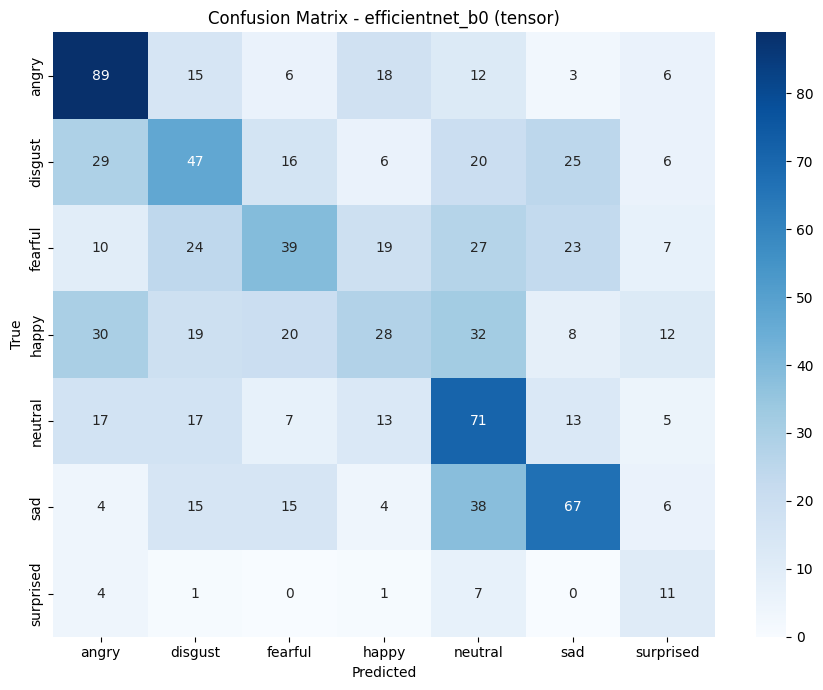

In [19]:

def evaluate_tensor_model_eff(model_arch, model_path, test_loader, class_names):
    model = TensorModelFactory.get_model(model_arch, num_classes=len(class_names), freeze_base=False)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()

    all_y, all_p = [], []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                logits = model(x)
            preds = logits.argmax(dim=1)

            all_y.extend(y.cpu().numpy())
            all_p.extend(preds.cpu().numpy())

    acc = accuracy_score(all_y, all_p)
    f1m = f1_score(all_y, all_p, average='macro', zero_division=0)
    print(f"Test Accuracy: {acc:.4f} | Test F1 macro: {f1m:.4f}\n")
    print(classification_report(all_y, all_p, target_names=class_names, zero_division=0))

    cm = confusion_matrix(all_y, all_p)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix - {model_arch} (tensor)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    del model
    torch.cuda.empty_cache()
    gc.collect()

evaluate_tensor_model_eff(MODEL_ARCH_1, best_phase2_eff, test_loader, class_names)

### Fine tuning con Resnet18

In [ ]:
set_global_seed(42)
cleanup_state()

In [ ]:
MODELS_SAVE_DIR = "/content/saved_models"
os.makedirs(MODELS_SAVE_DIR, exist_ok=True)
MODEL_ARCH_2 = 'resnet18'
exp_name_18 = f"tensor_{MODEL_ARCH_2}"

train_loader, val_loader, test_loader, class_names, class_weights = build_dataloaders()

phase1_path = os.path.join(MODELS_SAVE_DIR, f"{exp_name_18}resnet_fase1.pth")

model = TensorModelFactory.get_model(MODEL_ARCH_2, num_classes=len(class_names), freeze_base=True)

best_fase1_18 = train_model_tensor(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    save_path=phase1_path,
    epochs=20,
    lr=1e-3,
    patience=6,
    class_weights=class_weights
)

print("Fase 1 mejor modelo:", best_fase1_18)


Clases detectadas: ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Muestras -> Train: 7422 | Val: 830 | Test: 918
Shape ejemplo train[0]: (3, 13, 94) | label=3
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 119MB/s]


[01/15] lr=1.0e-03 | train_loss=1.9719 acc=0.2098 | val_loss=1.6907 acc=0.2988 f1m=0.3021
[02/15] lr=1.0e-03 | train_loss=1.7878 acc=0.2738 | val_loss=1.6602 acc=0.3217 f1m=0.3061
[03/15] lr=1.0e-03 | train_loss=1.7373 acc=0.2889 | val_loss=1.6092 acc=0.3663 f1m=0.3550
[04/15] lr=1.0e-03 | train_loss=1.6988 acc=0.3145 | val_loss=1.5805 acc=0.3687 f1m=0.3702
[05/15] lr=1.0e-03 | train_loss=1.6946 acc=0.3189 | val_loss=1.5989 acc=0.3711 f1m=0.3428
Early stop activado: 1/4
[06/15] lr=1.0e-03 | train_loss=1.6868 acc=0.3219 | val_loss=1.5777 acc=0.3711 f1m=0.3666
Early stop activado: 2/4
[07/15] lr=5.0e-04 | train_loss=1.6717 acc=0.3296 | val_loss=1.5864 acc=0.3518 f1m=0.3548
Early stop activado: 3/4
[08/15] lr=5.0e-04 | train_loss=1.6651 acc=0.3312 | val_loss=1.5882 acc=0.3639 f1m=0.3524
Early stop activado: 4/4
Early stopping.
Fase 1 mejor modelo: /content/saved_models/tensor_resnet18resnet_fase1.pth


In [ ]:
phase2_path = os.path.join(MODELS_SAVE_DIR, f"{exp_name_18}_phase2_unfrozen.pth")

model.load_state_dict(torch.load(best_fase1_18, map_location=device, weights_only=True))
for p in model.parameters():
    p.requires_grad = True

best_fase2_18 = train_model_tensor(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    save_path=phase2_path,
    epochs=40,
    lr=3e-5,
    backbone_lr=1e-5,
    weight_decay=1e-3,
    patience=6,
    class_weights=class_weights
)

print("Fase 2 mejor modelo resnet:", best_fase2_18)

[01/25] lr=1.0e-05 | train_loss=1.6002 acc=0.3645 | val_loss=1.4528 acc=0.4325 f1m=0.4228
[02/25] lr=1.0e-05 | train_loss=1.4290 acc=0.4353 | val_loss=1.3991 acc=0.4735 f1m=0.4665
[03/25] lr=1.0e-05 | train_loss=1.3009 acc=0.5018 | val_loss=1.3689 acc=0.4747 f1m=0.4681
[04/25] lr=1.0e-05 | train_loss=1.1971 acc=0.5485 | val_loss=1.3377 acc=0.4795 f1m=0.4733
[05/25] lr=1.0e-05 | train_loss=1.0845 acc=0.5966 | val_loss=1.3263 acc=0.4819 f1m=0.4820
[06/25] lr=1.0e-05 | train_loss=0.9958 acc=0.6451 | val_loss=1.2975 acc=0.5096 f1m=0.5061
[07/25] lr=1.0e-05 | train_loss=0.8980 acc=0.6851 | val_loss=1.2925 acc=0.5024 f1m=0.5046
Early stop activado: 1/4
[08/25] lr=1.0e-05 | train_loss=0.8041 acc=0.7334 | val_loss=1.2991 acc=0.5012 f1m=0.4963
Early stop activado: 2/4
[09/25] lr=1.0e-05 | train_loss=0.7119 acc=0.7758 | val_loss=1.3087 acc=0.5024 f1m=0.5068
[10/25] lr=1.0e-05 | train_loss=0.6144 acc=0.8213 | val_loss=1.3061 acc=0.5024 f1m=0.5047
Early stop activado: 1/4
[11/25] lr=1.0e-05 | trai

Test Accuracy: 0.4586 | Test F1 macro: 0.4628

              precision    recall  f1-score   support

       angry       0.61      0.71      0.66       150
     disgust       0.35      0.37      0.36       150
     fearful       0.33      0.23      0.27       150
       happy       0.42      0.39      0.40       150
     neutral       0.50      0.44      0.47       144
         sad       0.49      0.55      0.52       150
   surprised       0.43      0.79      0.56        24

    accuracy                           0.46       918
   macro avg       0.45      0.50      0.46       918
weighted avg       0.45      0.46      0.45       918



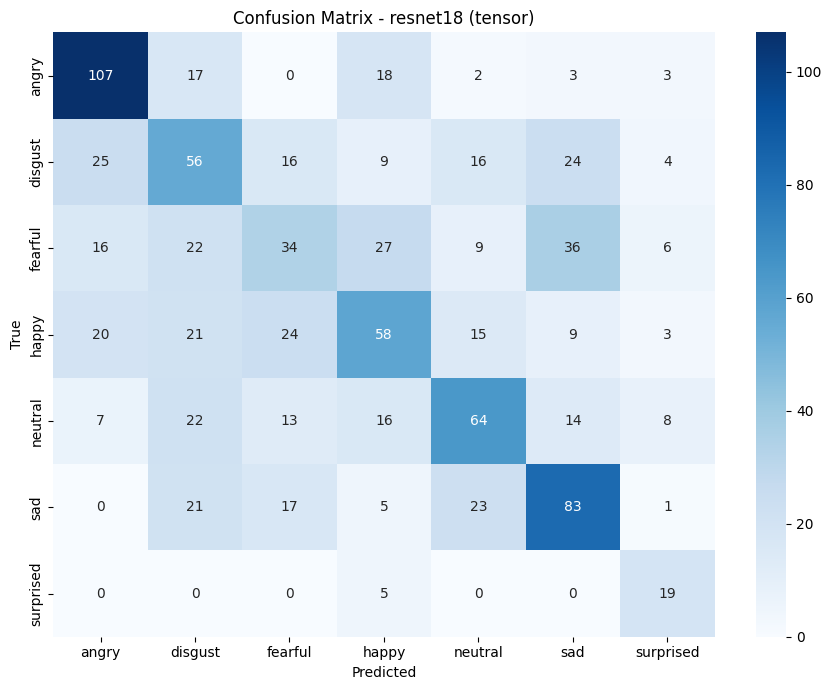

In [ ]:
def evaluate_tensor_model(model_arch, model_path, test_loader, class_names):
    model = TensorModelFactory.get_model(model_arch, num_classes=len(class_names), freeze_base=False)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()

    all_y, all_p = [], []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                logits = model(x)
            preds = logits.argmax(dim=1)

            all_y.extend(y.cpu().numpy())
            all_p.extend(preds.cpu().numpy())

    acc = accuracy_score(all_y, all_p)
    f1m = f1_score(all_y, all_p, average='macro', zero_division=0)
    print(f"Test Accuracy: {acc:.4f} | Test F1 macro: {f1m:.4f}\n")
    print(classification_report(all_y, all_p, target_names=class_names, zero_division=0))

    cm = confusion_matrix(all_y, all_p)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix - {model_arch} (tensor)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    del model
    torch.cuda.empty_cache()
    gc.collect()

evaluate_tensor_model(MODEL_ARCH_2, best_fase2_18, test_loader, class_names)

### Model Factory para Imagenes

ResNet18 y Efficientnet-b0

In [ ]:
set_global_seed(42)
cleanup_state()

In [ ]:
class ImageModelFactory:
    @staticmethod
    def get_model(model_name, num_classes, freeze_base=True):
        """
        Instancia dinámicamente arquitecturas convolucionales y adapta la última capa.
        """
        if model_name == 'resnet18':
            model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
            if freeze_base:
                for param in model.parameters(): param.requires_grad = False

            num_ftrs = model.fc.in_features
            model.fc = nn.Sequential(nn.Dropout(0.7), nn.Linear(num_ftrs, num_classes))

        elif model_name == 'efficientnet_b0':
            model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
            if freeze_base:
                for param in model.parameters(): param.requires_grad = False

            num_ftrs = model.classifier[1].in_features
            model.classifier[1] = nn.Sequential(nn.Dropout(0.5), nn.Linear(num_ftrs, num_classes))

        else:
            raise ValueError(f"Arquitectura {model_name} no soportada.")

        return model.to(device)

In [ ]:
def train_model(model, train_loader, val_loader, model_save_name, epochs=15, lr=1e-3, patience=5):
    """
    Bucle de entrenamiento con Mixed Precision (AMP) y Early Stopping y LR Scheduler.
    """
    criterion = nn.CrossEntropyLoss()
    # Optimiza solo los parámetros que requieren gradiente (útil en Phase 1)
    # Incrementamos weight_decay a 1e-2 para combatir el Overfitting observado
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=5e-2)

    # Configuramos el LR(Dinamico): Reduce el LR a la mitad si el val_loss no mejora en 2 épocas
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    scaler = torch.amp.GradScaler('cuda')

    best_val_loss = float('inf')
    trigger_times = 0
    save_path = os.path.join(MODELS_SAVE_DIR, f'{model_save_name}.pth')

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            # Forward pass con AMP para ahorro de memoria
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        # Phase de Validación
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        # Actualizamos el Scheduler basado en la métrica de validación
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        print(f"Epoch {epoch+1}/{epochs}[LR:{current_lr:.1e}] | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        # Early Stopping Logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)

        else:
            trigger_times += 1
            print(f"Early stop trigger activado {trigger_times} / {patience}")
            if trigger_times >= patience:
                print(f"--> Early Stopping disparado en época {epoch+1}.")
                break

    return save_path

In [ ]:

MODES = ['vector', 'png']
TARGET_FEATURE = 'mel_spec' # Opciones: 'mel_spec', 'mfcc'
MODEL_ARCHITECTURE = 'efficientnet_b0' # Opciones: 'resnet18', 'efficientnet_b0'

# Ensure 'device' refers to the torch.device object, not the sklearn function

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Carga de datos (usa los DataLoaders optimizados)
print(f"Cargando datos de: {TARGET_FEATURE.upper()}")
train_loader, val_loader, test_loader, class_names = get_images_dataloaders(TARGET_FEATURE)

# 2. Construcción dinámica mediante el Model Factory
model = ImageModelFactory.get_model(model_name=MODEL_ARCHITECTURE, num_classes=len(class_names), freeze_base=True)

experiment_name = f"{TARGET_FEATURE}_{MODEL_ARCHITECTURE}"

# =====================================================================
# FASE 1: TRANSFER LEARNING (Clasificador Superior)
# =====================================================================
print(f"\n--- INICIANDO FASE 1: Entrenando clasificador de {MODEL_ARCHITECTURE} ---")
best_model_path_phase1 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    model_save_name=f"{experiment_name}_phase1",
    epochs=15,
    lr=1e-3, # LR más alto porque solo entrenamos la capa lineal final
    patience=4
)

# =====================================================================
# FASE 2: FINE-TUNING PROFUNDO (Descongelamiento)
# =====================================================================
print(f"\n--- INICIANDO FASE 2: Fine-Tuning profundo ---")
# Restauramos el modelo al punto de menor pérdida en la Fase 1
model.load_state_dict(torch.load(best_model_path_phase1, weights_only=True))

# Descongelamos TODOS los pesos para que los filtros convolucionales se adapten al audio
for param in model.parameters():
    param.requires_grad = True

best_model_path_phase2 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    model_save_name=f"{experiment_name}_phase2_unfrozen",
    epochs=40,
    lr=1e-5, # CRÍTICO: LR drásticamente más bajo para no destruir los pesos de ImageNet
    patience=4
)

print(f"\nEntrenamiento Finalizado. Mejor modelo guardado en: {best_model_path_phase2}")

Cargando datos de: MEL_SPEC
[MEL_SPEC] Clases detectadas: ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Muestras -> Train: 7435 | Val: 824 | Test: 895

--- INICIANDO FASE 1: Entrenando clasificador de efficientnet_b0 ---
Epoch 1/15[LR:1.0e-03] | Train Loss: 1.6736 Acc: 0.3247 | Val Loss: 1.5513 Acc: 0.3883
Epoch 2/15[LR:1.0e-03] | Train Loss: 1.5165 Acc: 0.4070 | Val Loss: 1.5039 Acc: 0.4066
Epoch 3/15[LR:1.0e-03] | Train Loss: 1.4786 Acc: 0.4207 | Val Loss: 1.4881 Acc: 0.4041
Epoch 4/15[LR:1.0e-03] | Train Loss: 1.4555 Acc: 0.4296 | Val Loss: 1.4508 Acc: 0.4248
Epoch 5/15[LR:1.0e-03] | Train Loss: 1.4475 Acc: 0.4321 | Val Loss: 1.4620 Acc: 0.4284
Early stop trigger activado 1 / 4
Epoch 6/15[LR:1.0e-03] | Train Loss: 1.4310 Acc: 0.4416 | Val Loss: 1.4559 Acc: 0.4442
Early stop trigger activado 2 / 4
Epoch 7/15[LR:1.0e-03] | Train Loss: 1.4315 Acc: 0.4405 | Val Loss: 1.4305 Acc: 0.4600
Epoch 8/15[LR:1.0e-03] | Train Loss: 1.4314 Acc: 0.4402 | Val Loss: 1.4440 A

In [ ]:
set_global_seed(42)
cleanup_state()

In [ ]:
import shutil
# Guardamos los modelos para la siguiente fase (Late fusion)
output_filename = '/content/saved_models'
shutil.make_archive(output_filename, 'zip', MODELS_SAVE_DIR)

# Renombrar el archivo zip para que tenga la extensión .zip
# Esto es un workaround para make_archive que no agrega la extensión por defecto si el base_name ya tiene algo parecido a una extensión.
import os
os.rename('/content/saved_models.zip', '/content/saved_models_final.zip')

!cp /content/saved_models_final.zip /content/drive/MyDrive/saved_models_img_and_tensor.zip